# Flipkart Reviews Sentiment Analysis

<img src='https://egirisim.com/wp-content/uploads/2021/07/flipkart-yatirim.jpg'>

Bu çalışmanın amacı, Flipkart ürün incelemeleri veri seti kullanılarak doğal dil işleme (NLP) teknikleri ile metin verilerinden duygu (sentiment) çıkarımı gerçekleştirmektir. Kullanıcılar tarafından yazılan yorumların olumlu, nötr veya olumsuz olarak sınıflandırılması hedeflenmiştir.

The aim of this study is to extract sentiment from text data using natural language processing (NLP) techniques with the Flipkart product review dataset. The goal is to classify user-written reviews as positive, neutral, or negative.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from collections import Counter
import neattext.functions as nfx
from nltk.corpus import stopwords

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/flipkart_reviews.csv")

### EDA

In [3]:
df.head()

,Product_name,Review,Rating
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_name  2304 non-null   object
 1   Review        2304 non-null   object
 2   Rating        2304 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 54.1+ KB


In [5]:
df.isnull().sum()

Product_name    0
Review          0
Rating          0
dtype: int64

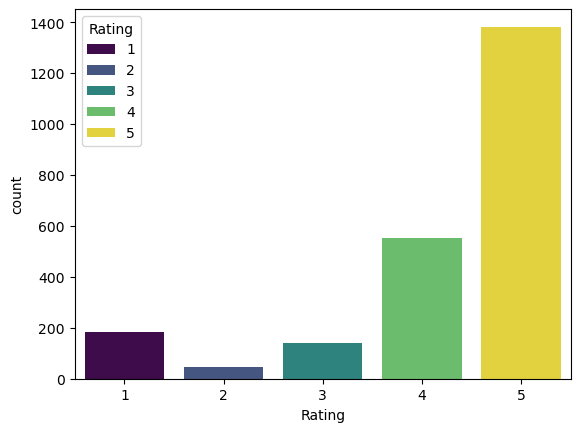

In [6]:
sns.countplot(x=df['Rating'], hue=df['Rating'], palette='viridis');

In [7]:
from langdetect import detect
df["language"] = df["Review"].apply(detect)

In [8]:
df["language"].value_counts()

language
en    1971
ro      81
so      67
af      44
pl      21
id      21
ca      14
fr      13
da      12
de      12
sl      10
vi       5
cs       5
it       5
fi       5
tl       5
no       4
et       3
hr       1
hu       1
sq       1
cy       1
es       1
sv       1
Name: count, dtype: int64

In [9]:
df = df[df["language"] == 'en']

In [10]:
df=df.reset_index(drop=True)

In [11]:
df.head()

,Product_name,Review,Rating,language
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,en
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,en
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,en
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,en
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,en


In [12]:
def label_sentiment(Rating):
    if Rating==1:
        return 'negative'
    elif Rating==2:
        return 'negative'
    elif Rating==3:
        return 'nutrol'
    else:
        return 'positive'

In [13]:
df['sentiment']= df['Rating'].apply(label_sentiment)

In [14]:
pd.set_option('display.max_colwidth', None)

In [15]:
df.head(10)

,Product_name,Review,Rating,language,sentiment
0,"Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600H - (8 GB/512 GB SSD/Windows 11 Home/4 GB Graphics/NVIDIA GeForce GTX 1650/120 Hz) 15ACH6 Gaming Laptop (15.6 inch, Shadow Black, 2.25$$kg kg)",Best under 60k Great performanceI got it for around 58500Battery backup is bit low but thanks to rapid charger its very fast Display is Ok for this price range Decent speakers with many customisation optionsVantage software is so good for customisationOverall good performance till nowWill update later if any problem occurs,5,en,positive
1,"Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600H - (8 GB/512 GB SSD/Windows 11 Home/4 GB Graphics/NVIDIA GeForce GTX 1650/120 Hz) 15ACH6 Gaming Laptop (15.6 inch, Shadow Black, 2.25$$kg kg)",Good perfomence...,5,en,positive
2,"Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600H - (8 GB/512 GB SSD/Windows 11 Home/4 GB Graphics/NVIDIA GeForce GTX 1650/120 Hz) 15ACH6 Gaming Laptop (15.6 inch, Shadow Black, 2.25$$kg kg)","Great performance but usually it has also that gaming laptop's issue of battery. It can only stand for 2 - 3 hrs without adapter. So, I prefer that use it with adaptor if you are using any software or playing games.",5,en,positive
3,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)",My wife is so happy and best product 👌🏻😘,5,en,positive
4,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)","Light weight laptop with new amazing features, battery life is awesome.",5,en,positive
5,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)","Amazing laptop, am so much happy, thanks for Flipkart.",5,en,positive
6,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)",Over all a good laptop for personal use,5,en,positive
7,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)",Thank you so much Flipkart,4,en,positive
8,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)",Amazing product,5,en,positive
9,"DELL Inspiron Athlon Dual Core 3050U - (4 GB/256 GB SSD/Windows 11 Home) INSPIRON 3515 Thin and Light Laptop (15.6 Inch, Carbon Black, 1.8 Kgs, With MS Office)","Good for normal work , students, online classes, watching movies etc.Not for havy tasks, gaming, buisness work, office work.editing etc.Overall good laptop in this range in budget laptops.",3,en,nutrol


In [65]:
d = {
    1: 0,
    2: 0,
    3: 1,
    4: 2,
    5: 2
}

df['sentiment'] = df['Rating'].map(d)

In [66]:
df['sentiment'].value_counts()

sentiment
2    1644
0     215
1     112
Name: count, dtype: int64

In [16]:
df['Review']=df['Review'].str.lower() # küçük harfe çeviriyor
df['Review']=df['Review'].str.replace('[^\w\s]','', regex=True) # noktolama işaretlerini kaldırır
df['Review']=df['Review'].str.replace('\d+','', regex=True) # rakamları kaldırır
df['Review']=df['Review'].str.replace('\n','', regex=True) # satır sonlarını kaldırır
df['Review']=df['Review'].str.replace('\r','', regex=True) # enter'ları kaldırıyor

In [17]:
df['Review'][0]

'best under k great performancei got it for around battery backup is bit low but thanks to rapid charger its very fast display is ok for this price range decent speakers with many customisation optionsvantage software is so good for customisationoverall good performance till nowwill update later if any problem occurs'

In [67]:
x = df['Review']
y = df[['sentiment']]

In [68]:
x.head()

0    best under k great performancei got it for around battery backup is bit low but thanks to rapid charger its very fast display is ok for this price range decent speakers with many customisation optionsvantage software is so good for customisationoverall good performance till nowwill update later if any problem occurs
1                                                                                                                                                                                                                                                                                                                  good perfomence
2                                                                                                                  great performance but usually it has also that gaming laptops issue of battery it can only stand for    hrs without adapter so i prefer that use it with adaptor if you are using any software or playing games
3                              

In [69]:
y

,sentiment
0,2
1,2
2,2
3,2
4,2
...,...
1966,2
1967,2
1968,2
1969,2


In [70]:
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

# NLTK durak kelimeleri indir
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
#tokenizasyon ve kök bulma (lematizasyon) 

In [72]:
def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [74]:
vect=CountVectorizer()

In [75]:
vect = CountVectorizer(ngram_range=(1, 2), analyzer=ekkok, stop_words='english')

In [76]:
#vect = CountVectorizer(ngram_range=(1, 2),max_features=20000, min_df=5, analyzer=ekkok, stop_words='english' )

In [77]:
x_vect = vect.fit_transform(x).toarray()

In [78]:
x_vect

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1971, 4401))

In [79]:
x_vect.shape

(1971, 4401)

In [80]:
x_train,x_test,y_train,y_test=train_test_split(x_vect,y,test_size=.2,random_state=42)

In [81]:
tf = pd.DataFrame(vect.transform(x).toarray(), columns=vect.get_feature_names_out())

In [82]:
tf

,aa,aab,aapka,ability,able,absence,absolute,absolutely,absurd,accept,...,yrr,yt,zaroor,zero,zonenow,zoom,zooming,zx,ßtill,ít
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1967,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1968,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1969,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(x_vect.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [85]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), epochs=20, verbose=2, callbacks=[early_stop])

Epoch 1/20
50/50 - 2s - 40ms/step - accuracy: 0.7989 - loss: 0.6832 - val_accuracy: 0.8380 - val_loss: 0.4578
Epoch 2/20
50/50 - 1s - 14ms/step - accuracy: 0.8477 - loss: 0.3830 - val_accuracy: 0.8810 - val_loss: 0.3136
Epoch 3/20
50/50 - 1s - 14ms/step - accuracy: 0.9245 - loss: 0.2293 - val_accuracy: 0.9418 - val_loss: 0.2126
Epoch 4/20
50/50 - 1s - 14ms/step - accuracy: 0.9638 - loss: 0.1335 - val_accuracy: 0.9544 - val_loss: 0.1775
Epoch 5/20
50/50 - 1s - 14ms/step - accuracy: 0.9784 - loss: 0.0880 - val_accuracy: 0.9570 - val_loss: 0.1627
Epoch 6/20
50/50 - 1s - 13ms/step - accuracy: 0.9835 - loss: 0.0652 - val_accuracy: 0.9646 - val_loss: 0.1598
Epoch 7/20
50/50 - 1s - 14ms/step - accuracy: 0.9879 - loss: 0.0475 - val_accuracy: 0.9646 - val_loss: 0.1803
Epoch 8/20
50/50 - 1s - 13ms/step - accuracy: 0.9892 - loss: 0.0406 - val_accuracy: 0.9646 - val_loss: 0.1760
Epoch 9/20
50/50 - 1s - 13ms/step - accuracy: 0.9886 - loss: 0.0349 - val_accuracy: 0.9646 - val_loss: 0.1954
Epoch 10/2

In [86]:
model.evaluate(x_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9646 - loss: 0.1598 


[0.15976537764072418, 0.9645569324493408]

In [90]:
neg = df[df['sentiment']==0]['Review'].iloc[0]
notr= df[df['sentiment']==1]['Review'].iloc[0]
pos= df[df['sentiment']==2]['Review'].iloc[0]

In [91]:
neg

'if you can affort few thousands extra you can prefer other laptops with same configi came to know about done limitations of this laptoppoor webcam not even suitable for day to day online classessound very low need to connect external speakerskeypad not visible due to same colour of laptop body and keys backlight not availablelow battery backupto save cost asus has done these compromisesperformance wise doesnt see any issue but since im using hp laptop also these small th'

In [92]:
pos

'best under k great performancei got it for around battery backup is bit low but thanks to rapid charger its very fast display is ok for this price range decent speakers with many customisation optionsvantage software is so good for customisationoverall good performance till nowwill update later if any problem occurs'

In [93]:
text1=vect.transform([neg]).toarray()
p1 = model.predict(text1)
label1 = p1.argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [94]:
label1

array([0])

In [95]:
text2=vect.transform([pos]).toarray()
p2= model.predict(text2)
label2 = p2.argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [96]:
label2

array([2])

In [99]:
#Şimdi en çok tekrar eden kelimeleri bulalım
s=' '.join(df['Review'])

In [100]:
Counter(s.split())

Counter({'is': 3227,
         'and': 2037,
         'good': 1832,
         'the': 1691,
         'this': 1577,
         'for': 1409,
         'i': 1312,
         'it': 1259,
         'very': 1166,
         'to': 1053,
         'in': 1053,
         'a': 903,
         'phone': 841,
         'of': 771,
         'not': 725,
         'camera': 703,
         'with': 677,
         'but': 632,
         'quality': 612,
         'you': 607,
         'product': 575,
         'its': 542,
         'price': 509,
         'best': 473,
         'battery': 449,
         'are': 417,
         'display': 388,
         'nice': 383,
         'so': 367,
         'also': 345,
         'at': 342,
         'as': 341,
         'on': 333,
         'tv': 330,
         'my': 326,
         'like': 319,
         'have': 308,
         'flipkart': 291,
         'awesome': 285,
         'no': 285,
         'performance': 281,
         'can': 273,
         'mobile': 270,
         'that': 266,
         'after': 266,
     

In [101]:
#stop wordsleri kaldıracağız şimdi
s2=nfx.remove_stopwords(s)

In [102]:
Counter(s2.split())

Counter({'good': 1832,
         'phone': 841,
         'camera': 703,
         'quality': 612,
         'product': 575,
         'price': 509,
         'best': 473,
         'battery': 449,
         'display': 388,
         'nice': 383,
         'tv': 330,
         'like': 319,
         'flipkart': 291,
         'awesome': 285,
         'performance': 281,
         'mobile': 270,
         'great': 255,
         'sound': 250,
         'money': 250,
         'delivery': 245,
         'fast': 239,
         'range': 218,
         'buy': 217,
         'better': 216,
         'use': 213,
         'value': 193,
         'days': 180,
         'time': 179,
         'happy': 170,
         'dont': 165,
         'samsung': 162,
         'realme': 149,
         'budget': 148,
         'screen': 147,
         'monitor': 144,
         'overall': 143,
         'picture': 142,
         'review': 135,
         'charging': 134,
         'low': 132,
         'design': 131,
         'day': 130,
         'a

In [111]:
negatif = df[df['sentiment'] == 0]
pozitif = df[df['sentiment'] == 2]

In [112]:
pozitifc=' '.join(pozitif['Review'])
pozitifc=nfx.remove_stopwords(pozitifc)

negatifc=' '.join(negatif['Review'])
negatifc=nfx.remove_stopwords(negatifc)

In [113]:
pozitif_data = Counter(pozitifc.split()).most_common(20)
pozitif_data = dict(pozitif_data)

negatif_data = Counter(negatifc.split()).most_common(20)
negatif_data = dict(negatif_data)

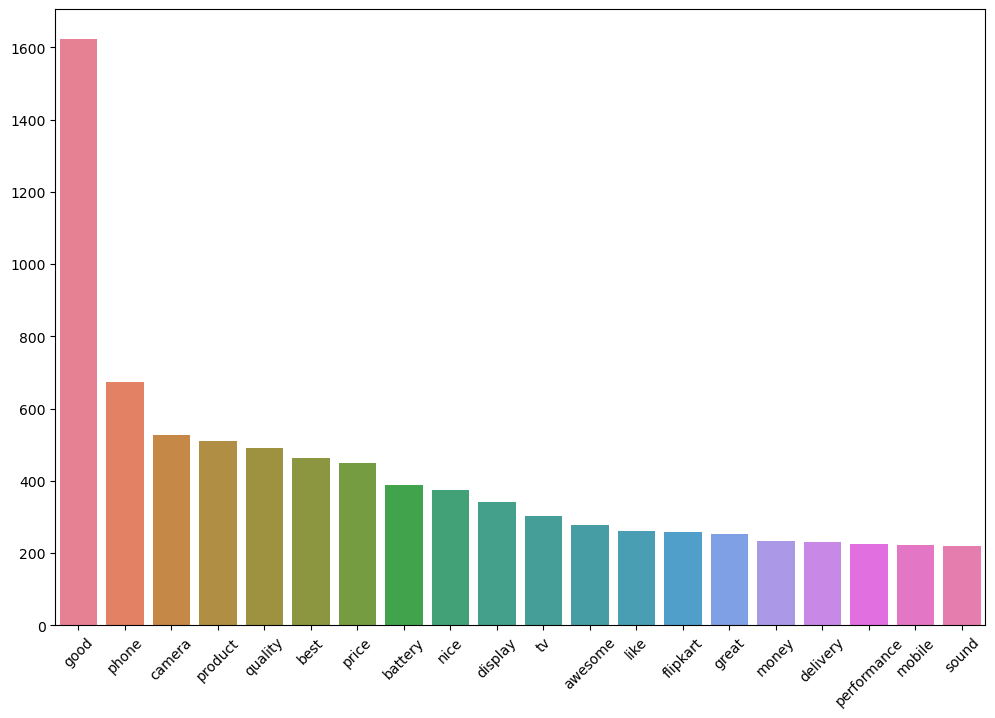

In [114]:
plt.figure(figsize=(12,8))
sns.barplot(x=pozitif_data.keys(), y=pozitif_data.values(), hue=pozitif_data.keys())
plt.xticks(rotation=45);

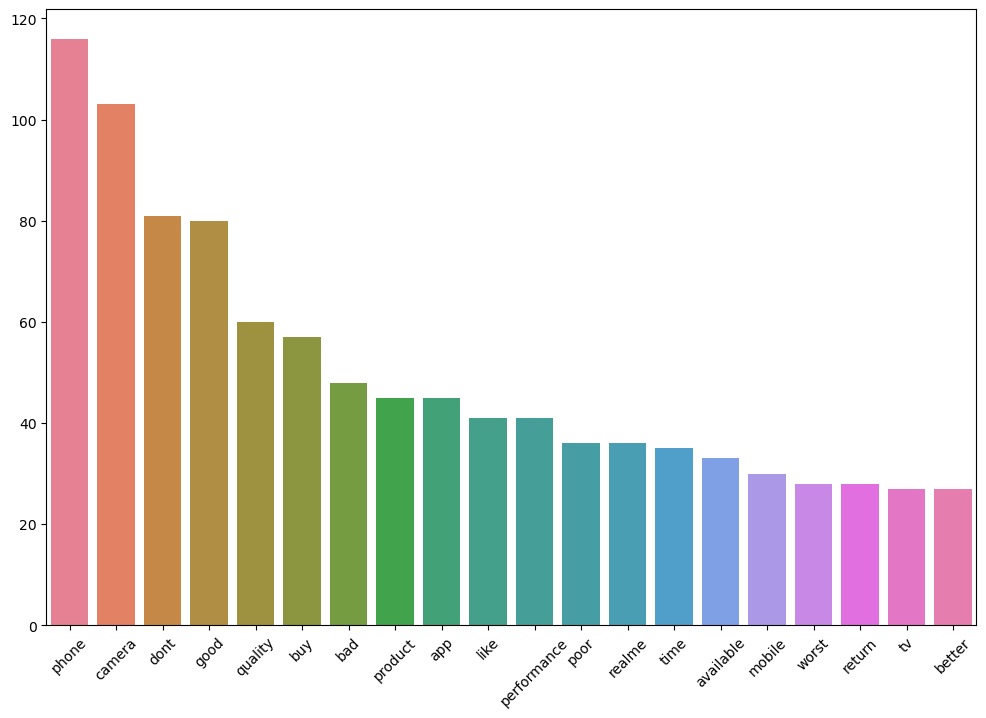

In [115]:
plt.figure(figsize=(12,8))
sns.barplot(x=negatif_data.keys(), y=negatif_data.values(), hue=negatif_data.keys())
plt.xticks(rotation=45);

In [116]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [117]:
def wc(data, color):
    plt.figure(figsize=(10, 10))
    mask=np.array(Image.open('cloud.png'))
    wc = WordCloud(background_color=color, stopwords=STOPWORDS, mask=mask)  
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')  
    plt.show() 

In [118]:
negatif = df[df['sentiment'] == 0]
pozitif = df[df['sentiment'] == 2]

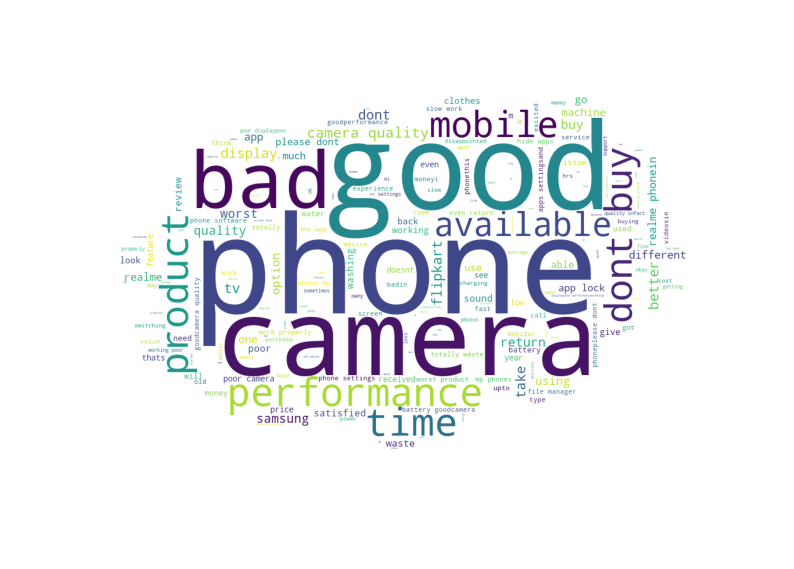

In [119]:
wc(negatif['Review'],'white')

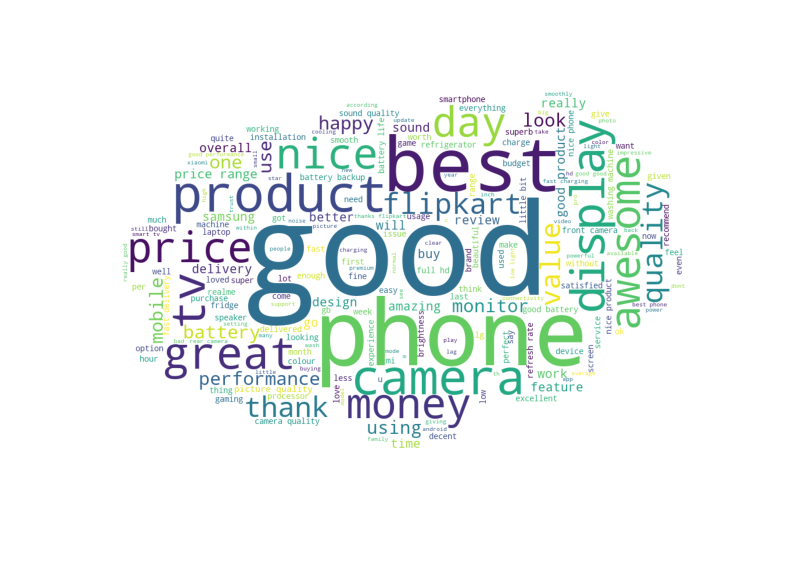

In [120]:
wc(pozitif['Review'],'white')

### Sentiment Analysis with machine learning

In [123]:
ybw=df[(df.Rating==1) | (df.Rating==3) | (df.Rating==5) ]

In [124]:
ybw.reset_index(drop=True, inplace=True)

In [125]:
x=ybw[['Review']]
y=ybw[['sentiment']]

In [126]:
x.head()

,Review
0,best under k great performancei got it for around battery backup is bit low but thanks to rapid charger its very fast display is ok for this price range decent speakers with many customisation optionsvantage software is so good for customisationoverall good performance till nowwill update later if any problem occurs
1,good perfomence
2,great performance but usually it has also that gaming laptops issue of battery it can only stand for hrs without adapter so i prefer that use it with adaptor if you are using any software or playing games
3,my wife is so happy and best product
4,light weight laptop with new amazing features battery life is awesome


In [127]:
y.head()

,sentiment
0,2
1,2
2,2
3,2
4,2


In [128]:
yenix=vect.fit_transform(x['Review'])

In [129]:
x_train, x_test, y_train, y_test=train_test_split(yenix,y, random_state=42, test_size=.20)

In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [131]:
algo_test(yenix,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[ 20   0  21]
 [  0   3  16]
 [  1   4 225]]
LogisticRegression()  modeli eğitiliyor!..
[[ 36   0   5]
 [  1  11   7]
 [  1   1 228]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[ 39   1   1]
 [  0  15   4]
 [  7   2 221]]
RandomForestClassifier()  modeli eğitiliyor!..
[[ 36   0   5]
 [  0  13   6]
 [  1   0 229]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[ 34   0   7]
 [  2   8   9]
 [  3   0 227]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[ 21   1  19]
 [  0   6  13]
 [  1   1 228]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[ 19   0  22]
 [  0   0  19]
 [  6   0 224]]
MultinomialNB()  modeli eğitiliyor!..
[[ 32   2   7]
 [  1   5  13]
 [  2   3 225]]
Eğitim tamamlandı.
En başarılı model:  RandomForestClassifier
Confusion Matrix:
[[ 36   0   5]
 [  0  13   6]
 [  1   0 229]]
classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92  

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.958621,0.958621,0.958621,0.958621
LogisticRegression,0.948276,0.948276,0.948276,0.948276
DecisionTreeClassifier,0.948276,0.948276,0.948276,0.948276
GradientBoostingClassifier,0.927586,0.927586,0.927586,0.927586
MultinomialNB,0.903448,0.903448,0.903448,0.903448
KNeighborsClassifier,0.879310,0.879310,0.879310,0.879310
BernoulliNB,0.855172,0.855172,0.855172,0.855172
AdaBoostClassifier,0.837931,0.837931,0.837931,0.837931


Makine öğrenmesi algoritmaları ile elde edilen sonuçlara göre en yüksek performans RandomForestClassifier modeli tarafından sağlanmış ve %95 doğruluk accuracy, precision, recall ve F1 skorlarına ulaşılmıştır. LogisticRegression ve DecisionTreeClassifier gibi diğer modeller de benzer şekilde yaklaşık %94 bandında performans göstermiştir. 

Derin öğrenme modeli ise %96 doğruluk oranı ve 0.15 loss değeri ile tüm makine öğrenmesi modellerine kıyasla daha yüksek bir performans sergilemiştir.

According to the results obtained with machine learning algorithms, the highest performance was provided by the RandomForestClassifier model, achieving 95% accuracy, precision, recall, and F1 scores. Other models such as LogisticRegression and DecisionTreeClassifier similarly showed performance in the approximately 94% range.

The deep learning model, however, exhibited higher performance compared to all machine learning models with a 96% accuracy rate and a loss value of 0.15.

In [132]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

r=RandomForestClassifier()
best_model=r.fit(x_train, y_train)

# Modelinizi ve vectorizer'ı kaydedin
joblib.dump(best_model, 'sentiment_model.joblib')
joblib.dump(vect, 'vectorizer.joblib')

['vectorizer.joblib']